#Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy import stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

#Loading Dataset

In [ ]:
df = pd.read_excel("DataSetSW_ANN.xlsx")

### Choosing only two dependant variables using a single model

In [ ]:
# Assume these are the independent features:
features = ["GDP", "Population", "GDP/Capita", "Literacy Rate", "Urban Population %", "HH Size"]

# And these are the multiple dependent variables to predict:
target_cols = ["MSW_tons/Capita/year", "Total_MSW_tons/year"] # change the subsets of dependant variables to experiment here

X = df[features]
y = df[target_cols]

#Removing Outliers

In [ ]:
print("Shape before outlier removal:", X.shape)
def remove_outliers_z(X, y, threshold= 3):
    data = pd.concat([X, y], axis=1)
    z_scores = np.abs(stats.zscore(data))
    mask = (z_scores < threshold).all(axis=1)
    return data[mask][X.columns], data[mask][y.columns]

X, y = remove_outliers_z(X, y)
print("Shape after outlier removal:", X.shape)

Shape before outlier removal: (161, 6)
Shape after outlier removal: (148, 6)


#Train Test Split and Normalization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale targets separately
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

#Modeling

In [ ]:
def build_model(num_layers=5, neurons=64, activation='relu'):
    model = Sequential()
    # Input layer + first hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(X_train_scaled.shape[1],)))
    # Additional hidden layers if num_layers > 1
    for _ in range(num_layers - 1):
        model.add(Dense(neurons, activation=activation))
    # Output layer: one neuron per target variable
    model.add(Dense(len(target_cols), activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

#Hyperparameter Tuning

In [ ]:
param_grid = {
    'num_layers': [9],
    'neurons': [47],
    'activation': ['relu'] # 'tanh'
}

best_score = -np.inf
best_params = {}
best_model = None
best_history = None

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

# Grid search with validation split during training
for num_layers in param_grid['num_layers']:
    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:
            print(f"Training model with {num_layers} layers, {neurons} neurons, activation={activation}")
            model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
            history = model.fit(X_train_scaled, y_train_scaled,
                                validation_split=0.2,
                                epochs=10000,
                                batch_size=20,
                                callbacks=[early_stop],
                                verbose=0)
            # Predict on test set and inverse scale predictions
            y_pred_scaled = model.predict(X_test_scaled, verbose=0)
            y_pred = scaler_y.inverse_transform(y_pred_scaled)
            # Compute R² for each target and average them
            r2_scores = []
            for i, col in enumerate(target_cols):
                r2 = r2_score(y_test[col], y_pred[:, i])
                r2_scores.append(r2)
            avg_r2 = np.mean(r2_scores)
            print(f"Avg R2: {avg_r2:.4f} | R2 per target: {np.round(r2_scores,4)}")

            if avg_r2 > best_score:
                best_score = avg_r2
                best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
                best_model = model
                best_history = history

print("\nBest Hyperparameters:", best_params)
print("Best Average Test R2 Score:", best_score)

Training model with 9 layers, 47 neurons, activation=relu


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: 0.7473 | R2 per target: [0.749  0.7457]

Best Hyperparameters: {'num_layers': 9, 'neurons': 47, 'activation': 'relu'}
Best Average Test R2 Score: 0.7473482239928322


#Training and Validation Loss Plot

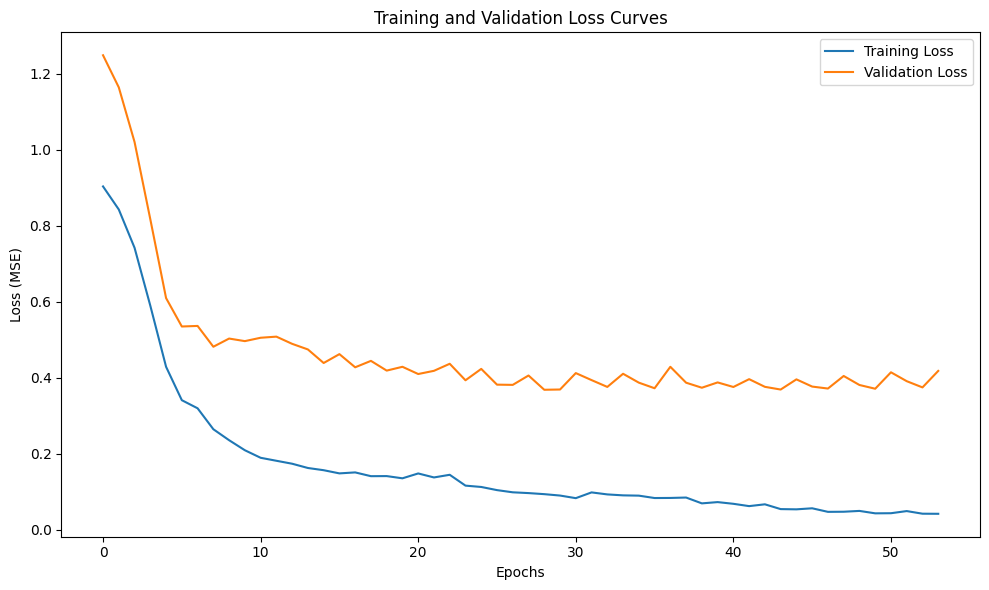

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Evaluate the Best Model on the Test Set
y_pred_best_scaled = best_model.predict(X_test_scaled, verbose=0)
y_pred_best = scaler_y.inverse_transform(y_pred_best_scaled)

print("\nFinal R² Scores on Test Set:")
for i, col in enumerate(target_cols):
    r2 = r2_score(y_test[col], y_pred_best[:, i])
    print(f"{col}: {r2:.4f}")


Final R² Scores on Test Set:
MSW_tons/Capita/year: 0.7980
Total_MSW_tons/year: 0.7094


#To Plot R2 of training and testing

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.callbacks import Callback, EarlyStopping
# from sklearn.metrics import r2_score
# import matplotlib.pyplot as plt

# # Custom callback to compute Train & Test R² at each epoch
# class R2Callback(Callback):
#     def __init__(self, X_train, y_train, X_test, y_test, scaler_y, target_cols):
#         self.X_train = X_train
#         self.y_train = y_train
#         self.X_test = X_test
#         self.y_test = y_test
#         self.scaler_y = scaler_y
#         self.target_cols = target_cols
#         self.train_r2_scores = []
#         self.test_r2_scores = []

#     def on_epoch_end(self, epoch, logs=None):
#         # Train Predictions & R²
#         y_train_pred_scaled = self.model.predict(self.X_train, verbose=0)
#         y_train_pred = self.scaler_y.inverse_transform(y_train_pred_scaled)
#         train_r2_scores = [r2_score(self.y_train[col], y_train_pred[:, i]) for i, col in enumerate(self.target_cols)]
#         avg_train_r2 = np.mean(train_r2_scores)
#         self.train_r2_scores.append(avg_train_r2)

#         # Test Predictions & R²
#         y_test_pred_scaled = self.model.predict(self.X_test, verbose=0)
#         y_test_pred = self.scaler_y.inverse_transform(y_test_pred_scaled)
#         test_r2_scores = [r2_score(self.y_test[col], y_test_pred[:, i]) for i, col in enumerate(self.target_cols)]
#         avg_test_r2 = np.mean(test_r2_scores)
#         self.test_r2_scores.append(avg_test_r2)

#         print(f"Epoch {epoch+1}: Train Avg R² = {avg_train_r2:.4f}, Test Avg R² = {avg_test_r2:.4f}")

# # Define parameter grid
# param_grid = {
#     'num_layers': [9],
#     'neurons': [47],
#     'activation': ['relu']  # 'tanh'
# }

# best_score = -np.inf
# best_params = {}
# best_model = None
# best_history = None
# best_train_r2 = None
# best_test_r2 = None

# early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

# # Grid search with validation split during training
# for num_layers in param_grid['num_layers']:
#     for neurons in param_grid['neurons']:
#         for activation in param_grid['activation']:
#             print(f"Training model with {num_layers} layers, {neurons} neurons, activation={activation}")
#             model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)

#             # Initialize R² callback
#             r2_callback = R2Callback(X_train_scaled, y_train, X_test_scaled, y_test, scaler_y, target_cols)

#             # Train model
#             history = model.fit(X_train_scaled, y_train_scaled,
#                                 validation_split=0.2,
#                                 epochs=100,
#                                 batch_size=10,
#                                 callbacks=[early_stop, r2_callback],
#                                 verbose=0)

#             # Predict on test set and inverse scale predictions
#             y_pred_scaled = model.predict(X_test_scaled, verbose=0)
#             y_pred = scaler_y.inverse_transform(y_pred_scaled)

#             # Compute R² for each target and average them
#             r2_scores = [r2_score(y_test[col], y_pred[:, i]) for i, col in enumerate(target_cols)]
#             avg_r2 = np.mean(r2_scores)
#             print(f"Avg R2: {avg_r2:.4f} | R2 per target: {np.round(r2_scores,4)}")

#             # Store best model
#             if avg_r2 > best_score:
#                 best_score = avg_r2
#                 best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
#                 best_model = model
#                 best_history = history
#                 best_train_r2 = r2_callback.train_r2_scores
#                 best_test_r2 = r2_callback.test_r2_scores

# # Plot Train vs Test Avg R² over epochs for the best model
# plt.figure(figsize=(10, 5))
# plt.plot(best_train_r2, label="Train R²", color='blue')
# plt.plot(best_test_r2, label="Test R²", color='red')
# plt.xlabel("Epoch")
# plt.ylabel("R² Score")
# plt.title("Train vs Test R² Score Over Epochs")
# plt.legend()
# plt.show()

# print("\nBest Hyperparameters:", best_params)
# print("Best Average Test R² Score:", best_score)


#With all evaluation parameter

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.callbacks import Callback, EarlyStopping
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import matplotlib.pyplot as plt

# def mean_absolute_percentage_error(y_true, y_pred):
#     return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# # Custom callback to compute Train & Test R² at each epoch
# class R2Callback(Callback):
#     def __init__(self, X_train, y_train, X_test, y_test, scaler_y, target_cols):
#         self.X_train = X_train
#         self.y_train = y_train
#         self.X_test = X_test
#         self.y_test = y_test
#         self.scaler_y = scaler_y
#         self.target_cols = target_cols
#         self.train_r2_scores = []
#         self.test_r2_scores = []

#     def on_epoch_end(self, epoch, logs=None):
#         # Train Predictions & R²
#         y_train_pred_scaled = self.model.predict(self.X_train, verbose=0)
#         y_train_pred = self.scaler_y.inverse_transform(y_train_pred_scaled)
#         train_r2_scores = [r2_score(self.y_train[col], y_train_pred[:, i]) for i, col in enumerate(self.target_cols)]
#         avg_train_r2 = np.mean(train_r2_scores)
#         self.train_r2_scores.append(avg_train_r2)

#         # Test Predictions & R²
#         y_test_pred_scaled = self.model.predict(self.X_test, verbose=0)
#         y_test_pred = self.scaler_y.inverse_transform(y_test_pred_scaled)
#         test_r2_scores = [r2_score(self.y_test[col], y_test_pred[:, i]) for i, col in enumerate(self.target_cols)]
#         avg_test_r2 = np.mean(test_r2_scores)
#         self.test_r2_scores.append(avg_test_r2)

#         print(f"Epoch {epoch+1}: Train Avg R² = {avg_train_r2:.4f}, Test Avg R² = {avg_test_r2:.4f}")

# # Define parameter grid
# param_grid = {'num_layers': [10], 'neurons': [60], 'activation': ['relu']}

# best_score = -np.inf
# best_params = {}
# best_model = None
# best_history = None
# best_train_r2 = None
# best_test_r2 = None

# early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

# # Grid search with validation split during training
# for num_layers in param_grid['num_layers']:
#     for neurons in param_grid['neurons']:
#         for activation in param_grid['activation']:
#             print(f"Training model with {num_layers} layers, {neurons} neurons, activation={activation}")
#             model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)

#             # Initialize R² callback
#             r2_callback = R2Callback(X_train_scaled, y_train, X_test_scaled, y_test, scaler_y, target_cols)

#             # Train model
#             history = model.fit(X_train_scaled, y_train_scaled,
#                                 validation_split=0.2,
#                                 epochs=100,
#                                 batch_size=20,
#                                 callbacks=[early_stop, r2_callback],
#                                 verbose=0)

#             # Predict on test set and inverse scale predictions
#             y_pred_scaled = model.predict(X_test_scaled, verbose=0)
#             y_pred = scaler_y.inverse_transform(y_pred_scaled)

#             # Ensure proper shape for metrics
#             y_pred = y_pred.reshape(-1, y_pred.shape[-1])

#             # Compute metrics for each target
#             r2_scores = [r2_score(y_test[col], y_pred[:, i]) for i, col in enumerate(target_cols)]
#             mae_scores = [mean_absolute_error(y_test[col], y_pred[:, i]) for i, col in enumerate(target_cols)]
#             mape_scores = [mean_absolute_percentage_error(y_test[col], y_pred[:, i]) for i, col in enumerate(target_cols)]
#             rmse_scores = [np.sqrt(mean_squared_error(y_test[col], y_pred[:, i])) for i, col in enumerate(target_cols)]

#             avg_r2 = np.mean(r2_scores)
#             avg_mae = np.mean(mae_scores)
#             avg_mape = np.mean(mape_scores)
#             avg_rmse = np.mean(rmse_scores)

#             print(f"Avg R2: {avg_r2:.4f}, Avg MAE: {avg_mae:.2E}, Avg MAPE: {avg_mape:.2f}, Avg RMSE: {avg_rmse:.2E} | "
#                   f"R2 per target: {np.round(r2_scores, 4)}")

#             # Store best model
#             if avg_r2 > best_score:
#                 best_score = avg_r2
#                 best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
#                 best_model = model
#                 best_history = history
#                 best_train_r2 = r2_callback.train_r2_scores
#                 best_test_r2 = r2_callback.test_r2_scores

# # Plot Train vs Test Avg R² over epochs for the best model
# plt.figure(figsize=(10, 5))
# plt.plot(best_train_r2, label="Train R²", color='blue')
# plt.plot(best_test_r2, label="Test R²", color='red')
# plt.xlabel("Epoch")
# plt.ylabel("R² Score")
# plt.title("Train vs Test R² Score Over Epochs")
# plt.legend()
# plt.show()

# print("\nBest Hyperparameters:", best_params)
# print(f"Best Average Test R² Score: {best_score:.4f}")
